## Punzi Figure of Merit

In rare decay searches, the goal is not classification accuracy but maximizing sensitivity.

The Punzi Figure of Merit (FOM) is defined as:

FOM = ε_signal / (a/2 + sqrt(N_background))

where:
- ε_signal = signal efficiency
- N_background = expected background in signal region
- a = number of sigma (we use a = 3 for 3σ sensitivity)

Why not S/√B?

- S/√B assumes known signal yield
- In rare searches, signal is unknown
- Punzi FOM optimizes selection BEFORE seeing signal

Reference:
G. Punzi, physics/0308063 (2003)

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import xgboost as xgb
import uproot
import os

os.makedirs("D:/b_meson_analysis/plots", exist_ok=True)
os.makedirs("D:/b_meson_analysis/results", exist_ok=True)

# Load data
df = uproot.open("D:/b_meson_analysis/data/B2HHH_MagnetDown.root")["DecayTree"].arrays(library="pd")

# Load model
model = xgb.XGBClassifier()
model.load_model("D:/b_meson_analysis/src/bdt_model.json")

# Load features
with open("D:/b_meson_analysis/src/features.txt") as f:
    features = [line.strip() for line in f.readlines()]

print("Loaded model and features")

Loaded model and features


In [6]:
# ================================
# Reconstruct B invariant mass (MANDATORY)
# ================================

m_pi = 139.57  # MeV

def compute_energy(px, py, pz, m):
    return np.sqrt(px**2 + py**2 + pz**2 + m**2)

E1 = compute_energy(df["H1_PX"], df["H1_PY"], df["H1_PZ"], m_pi)
E2 = compute_energy(df["H2_PX"], df["H2_PY"], df["H2_PZ"], m_pi)
E3 = compute_energy(df["H3_PX"], df["H3_PY"], df["H3_PZ"], m_pi)

px_tot = df["H1_PX"] + df["H2_PX"] + df["H3_PX"]
py_tot = df["H1_PY"] + df["H2_PY"] + df["H3_PY"]
pz_tot = df["H1_PZ"] + df["H2_PZ"] + df["H3_PZ"]

E_tot = E1 + E2 + E3

df["B_M"] = np.sqrt(np.maximum(E_tot**2 - (px_tot**2 + py_tot**2 + pz_tot**2), 0))

print("B_M reconstructed successfully")

B_M reconstructed successfully


In [7]:
# ================================
# COMPLETE FEATURE ENGINEERING (SAFE)
# ================================

# -------- Basic logs --------
df["log_IPCHI2_1"] = np.log10(np.clip(df["H1_IPChi2"], 1e-6, None))
df["log_IPCHI2_2"] = np.log10(np.clip(df["H2_IPChi2"], 1e-6, None))
df["log_IPCHI2_3"] = np.log10(np.clip(df["H3_IPChi2"], 1e-6, None))

df["log_FD"] = np.log10(np.clip(df["B_FlightDistance"], 1e-6, None))

df["vertex_chi2"] = df["B_VertexChi2"]

# -------- PID --------
df["PID_h1"] = df["H1_ProbK"] - df["H1_ProbPi"]
df["PID_h2"] = df["H2_ProbK"] - df["H2_ProbPi"]
df["PID_h3"] = df["H3_ProbK"] - df["H3_ProbPi"]

df["PID_sum"] = df["PID_h1"] + df["PID_h2"] + df["PID_h3"]

# -------- PT --------
df["H1_PT"] = np.sqrt(df["H1_PX"]**2 + df["H1_PY"]**2)
df["H2_PT"] = np.sqrt(df["H2_PX"]**2 + df["H2_PY"]**2)
df["H3_PT"] = np.sqrt(df["H3_PX"]**2 + df["H3_PY"]**2)

df["sum_PT"] = df["H1_PT"] + df["H2_PT"] + df["H3_PT"]

# -------- IPChi2 --------
df["IPCHI2_sum"] = df["H1_IPChi2"] + df["H2_IPChi2"] + df["H3_IPChi2"]
df["IPCHI2_max"] = df[["H1_IPChi2","H2_IPChi2","H3_IPChi2"]].max(axis=1)
df["IPCHI2_std"] = df[["H1_IPChi2","H2_IPChi2","H3_IPChi2"]].std(axis=1)

# -------- Asymmetry --------
df["PT_asym"] = (df["H1_PT"] - df["H2_PT"]) / (df["H1_PT"] + df["H2_PT"] + 1e-6)

# -------- Momentum --------
df["P1"] = np.sqrt(df["H1_PX"]**2 + df["H1_PY"]**2 + df["H1_PZ"]**2)
df["P2"] = np.sqrt(df["H2_PX"]**2 + df["H2_PY"]**2 + df["H2_PZ"]**2)
df["P3"] = np.sqrt(df["H3_PX"]**2 + df["H3_PY"]**2 + df["H3_PZ"]**2)

df["P_sum"] = df["P1"] + df["P2"] + df["P3"]
df["P_asym"] = (df["P1"] - df["P2"]) / (df["P1"] + df["P2"] + 1e-6)

# -------- Pairwise --------
df["PT_diff_12"] = np.abs(df["H1_PT"] - df["H2_PT"])
df["PT_diff_23"] = np.abs(df["H2_PT"] - df["H3_PT"])

print("All features created successfully.")

All features created successfully.


In [8]:
df["bdt_score"] = model.predict_proba(df[features])[:,1]

print("BDT scores computed")

BDT scores computed


In [9]:
signal_window = (5220, 5340)
sideband_low = (5100, 5220)
sideband_high = (5340, 5500)

df_signal = df[
    (df["B_M"] > signal_window[0]) &
    (df["B_M"] < signal_window[1])
]

df_sideband = df[
    ((df["B_M"] > sideband_low[0]) & (df["B_M"] < sideband_low[1])) |
    ((df["B_M"] > sideband_high[0]) & (df["B_M"] < sideband_high[1]))
]

print("Signal region:", df_signal.shape)
print("Sideband:", df_sideband.shape)

Signal region: (444867, 52)
Sideband: (814049, 52)


In [10]:
thresholds = np.arange(0.05, 0.95, 0.01)

punzi_values = []
eff_signal_list = []
bkg_list = []

# Width scaling
signal_width = signal_window[1] - signal_window[0]
sideband_width = (sideband_low[1] - sideband_low[0]) + (sideband_high[1] - sideband_high[0])
scale_factor = signal_width / sideband_width

for t in thresholds:
    
    # Signal efficiency
    eps_signal = np.sum(df_signal["bdt_score"] > t) / len(df_signal)
    
    # Background count (scaled)
    n_bkg = np.sum(df_sideband["bdt_score"] > t) * scale_factor
    
    # Punzi FOM
    punzi = eps_signal / (1.5 + np.sqrt(n_bkg)) if n_bkg > 0 else 0
    
    punzi_values.append(punzi)
    eff_signal_list.append(eps_signal)
    bkg_list.append(n_bkg)

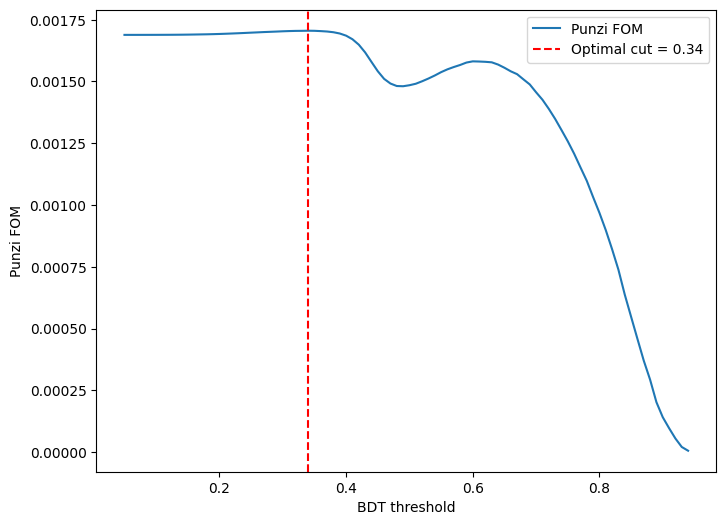

Optimal BDT cut: 0.34
Signal efficiency: 98.47%
Background: 331623.4 events


In [11]:
punzi_values = np.array(punzi_values)

best_idx = np.argmax(punzi_values)
best_cut = thresholds[best_idx]

plt.figure(figsize=(8,6))
plt.plot(thresholds, punzi_values, label="Punzi FOM")
plt.axvline(best_cut, color="red", linestyle="--", label=f"Optimal cut = {best_cut:.2f}")

plt.xlabel("BDT threshold")
plt.ylabel("Punzi FOM")
plt.legend()

plt.savefig("D:/b_meson_analysis/plots/punzi_scan.png", dpi=300)
plt.show()

print(f"Optimal BDT cut: {best_cut:.2f}")
print(f"Signal efficiency: {eff_signal_list[best_idx]*100:.2f}%")
print(f"Background: {bkg_list[best_idx]:.1f} events")

In [12]:
df_results = pd.DataFrame({
    "bdt_threshold": thresholds,
    "eps_signal": eff_signal_list,
    "N_bkg": bkg_list,
    "punzi_fom": punzi_values
})

df_results.to_csv("../results/selection_efficiency.csv", index=False)

print("Saved efficiency table")

Saved efficiency table


In [13]:
df_selected = df[df["bdt_score"] > best_cut]

df_selected.to_csv("D:/b_meson_analysis/data/selected_candidates.csv", index=False)

print("Selected candidates:", df_selected.shape)

Selected candidates: (4925024, 52)
